# 03 — Vetorização de Texto e Visualização Semântica (2D e 3D)

A **vetorização** converte textos pré-processados em representações numéricas para os modelos de Machine Learning.

Neste notebook, abordamos:
1. **Bag of Words (BoW)** e **TF-IDF**
2. **Nuvens de Palavras com BoW (Frequência) e com TF-IDF (Ponderação)** por classe
3. **Word2Vec** e **GloVe** (Embeddings densos)
4. **Visualização 2D e 3D de Embeddings (PCA)** para analisar a geometria do espaço semântico
5. Persistência dos splits vetorizados para o treinamento dos modelos

> **Pré-requisito:** O arquivo `data/processed/splits_texto.joblib` (gerado no Notebook 02) deve existir.

## 1. Importações e Carregamento dos Dados

In [95]:
%matplotlib inline

import sys
sys.path.append('..')

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from wordcloud import WordCloud
from sklearn.decomposition import PCA

from src.vectorization import (
    criar_bow, criar_tfidf,
    treinar_word2vec, textos_para_vetores_w2v,
    carregar_glove, textos_para_vetores_glove,
    ajustar_e_transformar, salvar_vetorizador
)

sns.set_theme(style='whitegrid')

# Carregar splits de texto gerados no notebook 02
X_train, X_test, y_train, y_test = joblib.load('../data/processed/splits_texto.joblib')
print(f'Treino: {len(X_train)} amostras | Teste: {len(X_test)} amostras')

Treino: 3021 amostras | Teste: 756 amostras


---
## 2. Bag of Words (BoW)

In [96]:
bow = criar_bow(max_features=5000)
X_train_bow, X_test_bow = ajustar_e_transformar(bow, X_train, X_test)

print(f'Shape X_train (BoW): {X_train_bow.shape}')
print(f'Shape X_test  (BoW): {X_test_bow.shape}')

Shape X_train (BoW): (3021, 3875)
Shape X_test  (BoW): (756, 3875)


### 2.1 Top 20 Palavras Mais Frequentes (BoW)

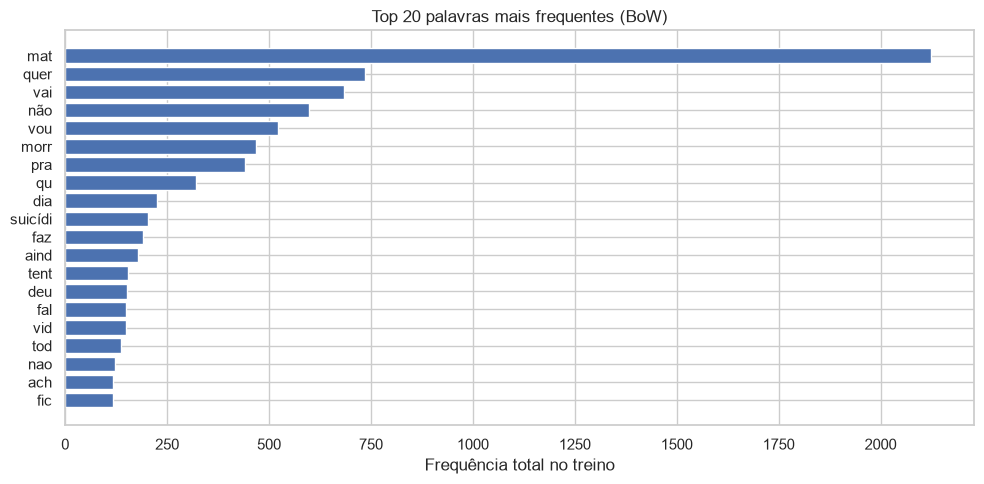

In [97]:
frequencias = np.asarray(X_train_bow.sum(axis=0)).flatten()
vocab = bow.get_feature_names_out()
top20 = sorted(zip(vocab, frequencias), key=lambda x: x[1], reverse=True)[:20]

palavras, contagens = zip(*top20)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(list(palavras)[::-1], list(contagens)[::-1], color='#4C72B0')
ax.set_xlabel('Frequência total no treino')
ax.set_title('Top 20 palavras mais frequentes (BoW)')
plt.tight_layout()
plt.show()

---
## 3. TF-IDF (Term Frequency–Inverse Document Frequency)

In [98]:
tfidf = criar_tfidf(max_features=5000, ngram_range=(1, 2))
X_train_tfidf, X_test_tfidf = ajustar_e_transformar(tfidf, X_train, X_test)

print(f'Shape X_train (TF-IDF): {X_train_tfidf.shape}')
print(f'Shape X_test  (TF-IDF): {X_test_tfidf.shape}')

Shape X_train (TF-IDF): (3021, 5000)
Shape X_test  (TF-IDF): (756, 5000)


### 3.1 Top 20 Termos com Maior Peso Médio (TF-IDF)

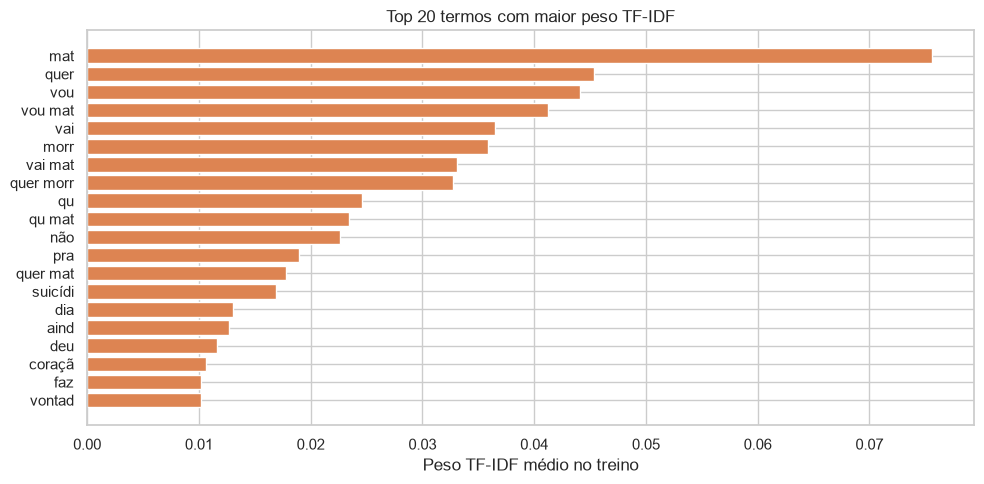

In [99]:
pesos_medios = np.asarray(X_train_tfidf.mean(axis=0)).flatten()
vocab_tfidf = tfidf.get_feature_names_out()
top20_tfidf = sorted(zip(vocab_tfidf, pesos_medios), key=lambda x: x[1], reverse=True)[:20]

palavras_t, pesos_t = zip(*top20_tfidf)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(list(palavras_t)[::-1], list(pesos_t)[::-1], color='#DD8452')
ax.set_xlabel('Peso TF-IDF médio no treino')
ax.set_title('Top 20 termos com maior peso TF-IDF')
plt.tight_layout()
plt.show()

---
## 4. Visualização: Nuvens de Palavras (BoW vs TF-IDF)

Comparamos duas formas de gerar nuvens de palavras:
1. **Por Frequência (BoW)**: baseada na contagem direta de ocorrências.
2. **Por Ponderação (TF-IDF)**: baseada no peso estatístico de relevância/raridade dos termos em cada classe.

### 4.1 Nuvens de Palavras por Frequência (BoW)

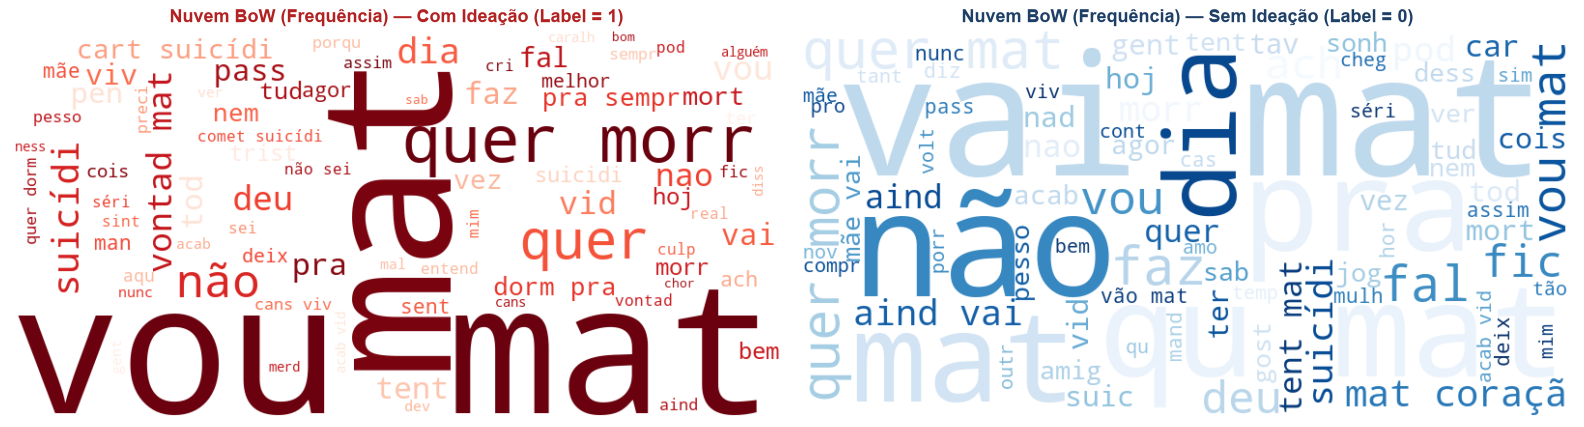

In [100]:
# Textos agrupados por classe
textos_ideacao = ' '.join(X_train[y_train == 1])
textos_sem_ideacao = ' '.join(X_train[y_train == 0])

wc_bow_1 = WordCloud(width=800, height=400, background_color='white', colormap='Reds', max_words=80).generate(textos_ideacao)
wc_bow_0 = WordCloud(width=800, height=400, background_color='white', colormap='Blues', max_words=80).generate(textos_sem_ideacao)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(wc_bow_1, interpolation='bilinear')
axes[0].set_title('Nuvem BoW (Frequência) — Com Ideação (Label = 1)', fontsize=13, fontweight='bold', color='#B22222')
axes[0].axis('off')

axes[1].imshow(wc_bow_0, interpolation='bilinear')
axes[1].set_title('Nuvem BoW (Frequência) — Sem Ideação (Label = 0)', fontsize=13, fontweight='bold', color='#1E3F66')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### 4.2 Nuvens de Palavras Ponderadas por Relevância (TF-IDF)

Calculamos o peso TF-IDF médio de cada termo dentro de cada classe, destacando as palavras mais discriminativas.

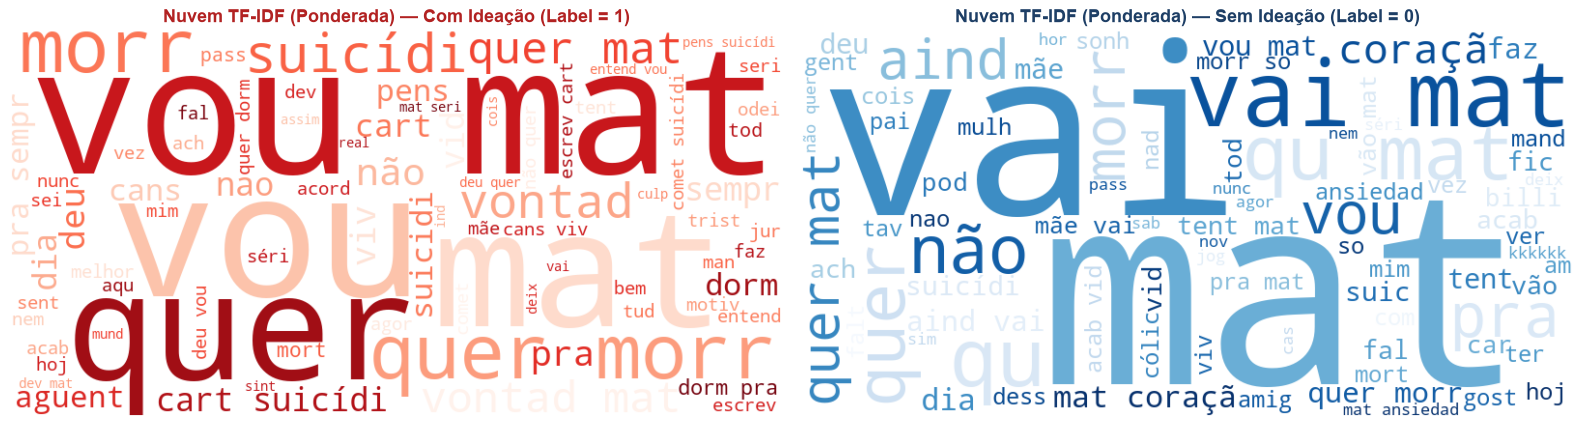

In [101]:
# Obter matrizes TF-IDF separadas por classe
idx_1 = np.where(y_train.values == 1)[0]
idx_0 = np.where(y_train.values == 0)[0]

pesos_tfidf_1 = np.asarray(X_train_tfidf[idx_1].mean(axis=0)).flatten()
pesos_tfidf_0 = np.asarray(X_train_tfidf[idx_0].mean(axis=0)).flatten()
termos = tfidf.get_feature_names_out()

freq_dict_1 = {termos[i]: float(pesos_tfidf_1[i]) for i in range(len(termos)) if pesos_tfidf_1[i] > 0}
freq_dict_0 = {termos[i]: float(pesos_tfidf_0[i]) for i in range(len(termos)) if pesos_tfidf_0[i] > 0}

wc_tfidf_1 = WordCloud(width=800, height=400, background_color='white', colormap='Reds', max_words=80).generate_from_frequencies(freq_dict_1)
wc_tfidf_0 = WordCloud(width=800, height=400, background_color='white', colormap='Blues', max_words=80).generate_from_frequencies(freq_dict_0)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].imshow(wc_tfidf_1, interpolation='bilinear')
axes[0].set_title('Nuvem TF-IDF (Ponderada) — Com Ideação (Label = 1)', fontsize=13, fontweight='bold', color='#B22222')
axes[0].axis('off')

axes[1].imshow(wc_tfidf_0, interpolation='bilinear')
axes[1].set_title('Nuvem TF-IDF (Ponderada) — Sem Ideação (Label = 0)', fontsize=13, fontweight='bold', color='#1E3F66')
axes[1].axis('off')

plt.tight_layout()
plt.show()

---
## 5. Word2Vec (Gensim Oficial)

In [102]:
print('Treinando Word2Vec no conjunto de treino...')
modelo_w2v = treinar_word2vec(X_train.tolist(), vector_size=100, window=5, min_count=2)
print(f'Vocabulário Word2Vec: {len(modelo_w2v.wv)} termos únicos')

X_train_w2v = textos_para_vetores_w2v(X_train.tolist(), modelo_w2v)
X_test_w2v  = textos_para_vetores_w2v(X_test.tolist(),  modelo_w2v)

print(f'Shape X_train (Word2Vec): {X_train_w2v.shape}')
print(f'Shape X_test  (Word2Vec): {X_test_w2v.shape}')

Treinando Word2Vec no conjunto de treino...
Vocabulário Word2Vec: 1989 termos únicos
Shape X_train (Word2Vec): (3021, 100)
Shape X_test  (Word2Vec): (756, 100)


---
## 6. GloVe (Embeddings Pré-treinados NILC-USP)

In [103]:
caminho_glove = '../data/embeddings/glove_s100.txt'

print(f'Carregando GloVe de {caminho_glove}...')
glove_dict, dim_glove = carregar_glove(caminho_glove)
X_train_glove = textos_para_vetores_glove(X_train.tolist(), glove_dict, vector_size=dim_glove)
X_test_glove  = textos_para_vetores_glove(X_test.tolist(),  glove_dict, vector_size=dim_glove)

print(f'Shape X_train (GloVe): {X_train_glove.shape}')
print(f'Shape X_test  (GloVe): {X_test_glove.shape}')

Carregando GloVe de ../data/embeddings/glove_s100.txt...
Embeddings carregados: 929592 palavras com dimensão 100.
Shape X_train (GloVe): (3021, 100)
Shape X_test  (GloVe): (756, 100)


---
## 7. Visualização Semântica dos Embeddings em 2D (PCA)

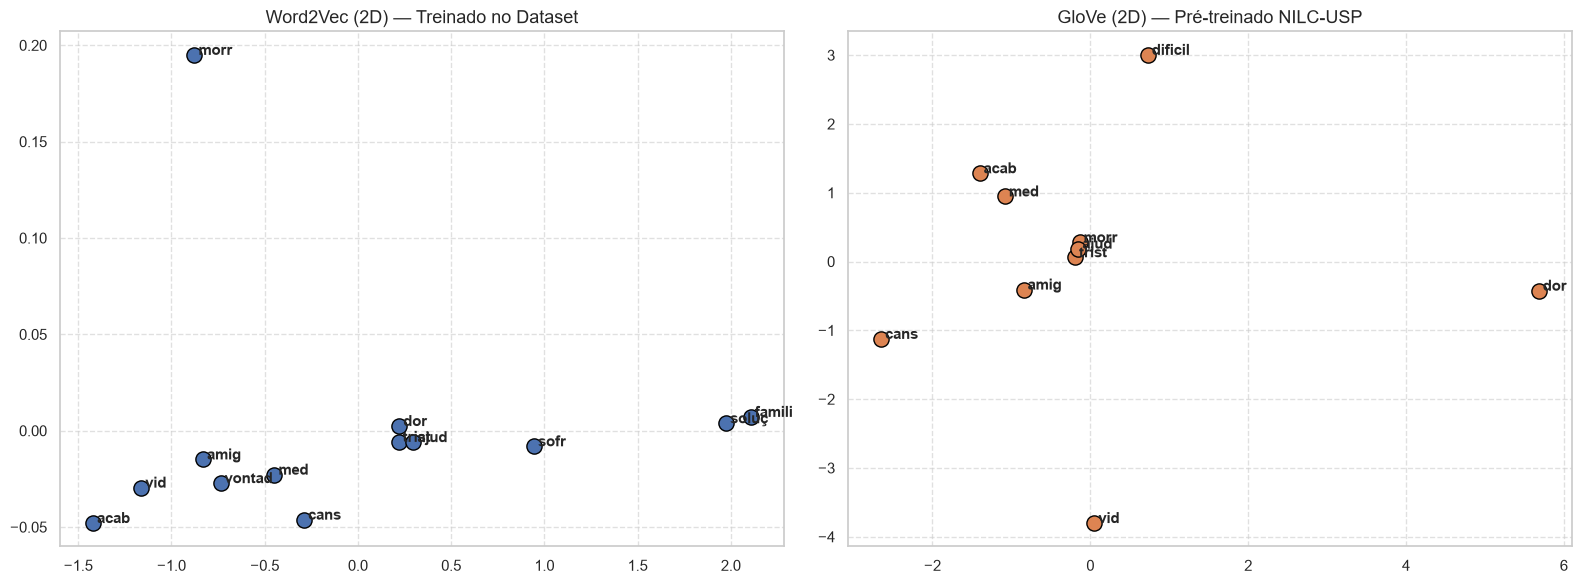

In [104]:
# Lista de palavras-chave para visualização semântica
palavras_alvo = [
    'vid', 'morr', 'acab', 'trist', 'sofr', 'dor', 'ajud', 
    'vontad', 'med', 'amig', 'famili', 'dificil', 'cans', 'soluç'
]

# 1. Coletar vetores presentes no Word2Vec
palavras_w2v = [p for p in palavras_alvo if p in modelo_w2v.wv]
vetores_w2v = np.array([modelo_w2v.wv[p] for p in palavras_w2v])

# 2. Coletar vetores presentes no GloVe
palavras_glv = [p for p in palavras_alvo if p in glove_dict]
vetores_glv = np.array([glove_dict[p] for p in palavras_glv])

pca_w2v_2d = PCA(n_components=2).fit_transform(vetores_w2v)
pca_glv_2d = PCA(n_components=2).fit_transform(vetores_glv)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Word2Vec 2D
axes[0].scatter(pca_w2v_2d[:, 0], pca_w2v_2d[:, 1], color='#4C72B0', s=120, edgecolors='black')
for i, p in enumerate(palavras_w2v):
    axes[0].annotate(f' {p}', (pca_w2v_2d[i, 0], pca_w2v_2d[i, 1]), fontsize=11, fontweight='bold')
axes[0].set_title('Word2Vec (2D) — Treinado no Dataset', fontsize=13)
axes[0].grid(True, linestyle='--', alpha=0.6)

# GloVe 2D
axes[1].scatter(pca_glv_2d[:, 0], pca_glv_2d[:, 1], color='#DD8452', s=120, edgecolors='black')
for i, p in enumerate(palavras_glv):
    axes[1].annotate(f' {p}', (pca_glv_2d[i, 0], pca_glv_2d[i, 1]), fontsize=11, fontweight='bold')
axes[1].set_title('GloVe (2D) — Pré-treinado NILC-USP', fontsize=13)
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

---
## 8. Visualização Semântica Tridimensional em 3D (PCA)

Projetamos os vetores de 100 dimensões em um espaço **tridimensional (3D)** com os 3 componentes principais de maior variância.

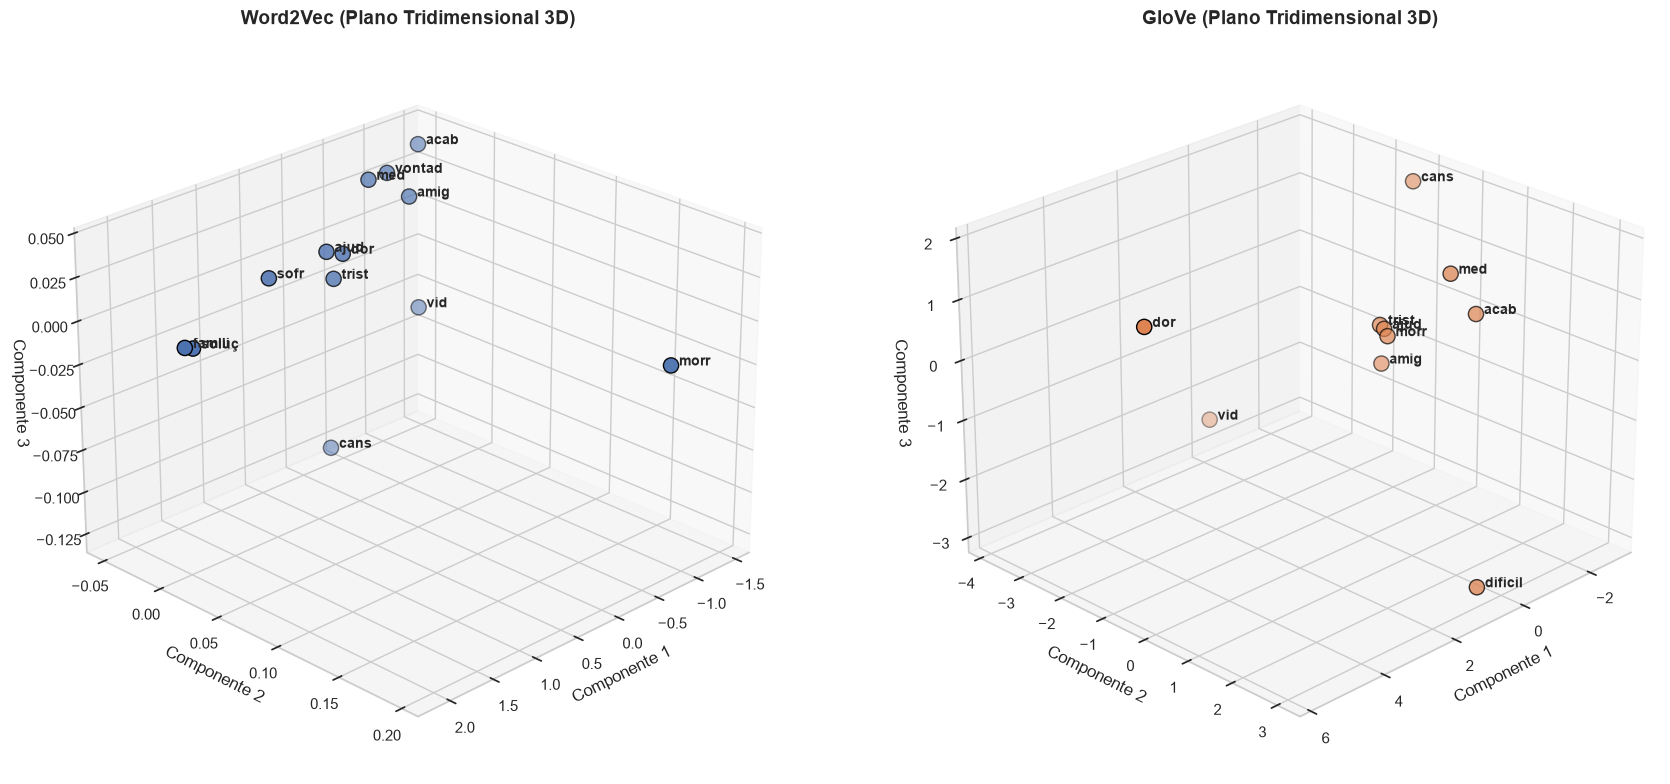

In [105]:
palavras_alvo = [
    'vid', 'morr', 'acab', 'trist', 'sofr', 'dor', 'ajud', 
    'vontad', 'med', 'amig', 'famili', 'dificil', 'cans', 'soluç'
]
palavras_w2v = [p for p in palavras_alvo if p in modelo_w2v.wv]
vetores_w2v = np.array([modelo_w2v.wv[p] for p in palavras_w2v])

palavras_glv = [p for p in palavras_alvo if p in glove_dict]
vetores_glv = np.array([glove_dict[p] for p in palavras_glv])

pca_w2v_3d = PCA(n_components=3).fit_transform(vetores_w2v)
pca_glv_3d = PCA(n_components=3).fit_transform(vetores_glv)

fig = plt.figure(figsize=(18, 8))

# 1. Word2Vec 3D
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.scatter(pca_w2v_3d[:, 0], pca_w2v_3d[:, 1], pca_w2v_3d[:, 2], color='#4C72B0', s=120, edgecolors='black', depthshade=True)
for i, p in enumerate(palavras_w2v):
    ax1.text(pca_w2v_3d[i, 0], pca_w2v_3d[i, 1], pca_w2v_3d[i, 2], f'  {p}', fontsize=10, fontweight='bold')

ax1.set_title('Word2Vec (Plano Tridimensional 3D)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Componente 1')
ax1.set_ylabel('Componente 2')
ax1.set_zlabel('Componente 3')
ax1.view_init(elev=25, azim=45)

# 2. GloVe 3D
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(pca_glv_3d[:, 0], pca_glv_3d[:, 1], pca_glv_3d[:, 2], color='#DD8452', s=120, edgecolors='black', depthshade=True)
for i, p in enumerate(palavras_glv):
    ax2.text(pca_glv_3d[i, 0], pca_glv_3d[i, 1], pca_glv_3d[i, 2], f'  {p}', fontsize=10, fontweight='bold')

ax2.set_title('GloVe (Plano Tridimensional 3D)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Componente 1')
ax2.set_ylabel('Componente 2')
ax2.set_zlabel('Componente 3')
ax2.view_init(elev=25, azim=45)

plt.tight_layout()
plt.show()

---
## 9. Comparação Geral das Técnicas de Vetorização

| Abordagem | Tipo | Representação | Captura Semântica | Dimensão Típica |
|---|---|---|---|---|
| **BoW** | Contagem | Esparsa | ❌ Não | Alta (5.000) |
| **TF-IDF** | Ponderação estatística | Esparsa | ❌ Não | Alta (5.000) |
| **Word2Vec** | Embedding local | Densa | ✅ Sim | Baixa (100) |
| **GloVe** | Embedding global | Densa | ✅ Sim | Baixa (100) |

---
## 10. Persistência dos Dados Vetorizados

In [106]:
# Salvar vetorizadores
salvar_vetorizador(bow,   '../results/metrics/bow_vectorizer.joblib')
salvar_vetorizador(tfidf, '../results/metrics/tfidf_vectorizer.joblib')
modelo_w2v.save('../results/metrics/word2vec.model')

# Salvar matrizes de features para treinamento
joblib.dump((X_train_bow,   X_test_bow,   y_train, y_test), '../data/processed/splits_bow.joblib')
joblib.dump((X_train_tfidf, X_test_tfidf, y_train, y_test), '../data/processed/splits_tfidf.joblib')
joblib.dump((X_train_w2v,   X_test_w2v,   y_train, y_test), '../data/processed/splits_w2v.joblib')
joblib.dump((X_train_glove, X_test_glove, y_train, y_test), '../data/processed/splits_glove.joblib')

print('✅ Todos os splits (BoW, TF-IDF, Word2Vec, GloVe) foram salvos em data/processed/!')

Vetorizador salvo em: ../results/metrics/bow_vectorizer.joblib
Vetorizador salvo em: ../results/metrics/tfidf_vectorizer.joblib
✅ Todos os splits (BoW, TF-IDF, Word2Vec, GloVe) foram salvos em data/processed/!
